In [1]:
pip install yfinance 

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np 
import yfinance as yf 
from datetime import datetime 


In [ ]:

# test data pulling
spx = yf.download("^GSPC", period="5d")
print(spx.head())


C:\Users\vijeet\AppData\Local\Temp\ipykernel_7140\2724333939.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx = yf.download("^GSPC", period="5d")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2025-11-20  6538.759766  6770.350098  6534.049805  6737.930176  5596080000
2025-11-21  6602.990234  6660.049805  6521.919922  6555.770020  5929930000
2025-11-24  6705.120117  6715.750000  6630.700195  6636.540039  6039740000
2025-11-25  6765.879883  6776.399902  6659.979980  6697.029785  5003330000
2025-11-26  6812.609863  6831.439941  6783.870117  6793.549805  4485000000


In [4]:
import yfinance as yf
import pandas as pd
from datetime import datetime


# ---------- 1. Define periods ----------
train_start = "2010-01-01"
train_end   = "2019-12-31"

val_start   = "2020-01-01"
val_end     = "2022-12-31"

test_start  = "2023-01-01"
test_end    = datetime.today().strftime("%Y-%m-%d")  # auto-updates to today


# ---------- 2. Function to download data ----------
def get_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end)
    df = df[['Close']]                   # only close prices
    df.columns = [ticker.replace("^","") + "_Close"]
    return df


tickers = ["^GSPC", "^NSEI", "^VIX"]


# ---------- 3. Training Data ----------
train_data = pd.concat(
    [get_data(t, train_start, train_end) for t in tickers],
    axis=1
)

# ---------- 4. Validation Data ----------
val_data = pd.concat(
    [get_data(t, val_start, val_end) for t in tickers],
    axis=1
)

# ---------- 5. Testing Data ----------
test_data = pd.concat(
    [get_data(t, test_start, test_end) for t in tickers],
    axis=1
)


# ---------- 6. Output shapes ----------
print("Training:", train_data.shape)
print("Validation:", val_data.shape)
print("Testing:", test_data.shape)

train_data.head()


C:\Users\vijeet\AppData\Local\Temp\ipykernel_12628\448420649.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
C:\Users\vijeet\AppData\Local\Temp\ipykernel_12628\448420649.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
C:\Users\vijeet\AppData\Local\Temp\ipykernel_12628\448420649.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
C:\Users\vijeet\AppData\Local\Temp\ipykernel_12628\448420649.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[************

Training: (2576, 3)
Validation: (778, 3)
Testing: (755, 3)


,GSPC_Close,NSEI_Close,VIX_Close
Date,,,
2010-01-04,1132.989990,5232.200195,20.040001
2010-01-05,1136.520020,5277.899902,19.350000
2010-01-06,1137.140015,5281.799805,19.160000
2010-01-07,1141.689941,5263.100098,19.059999
2010-01-08,1144.979980,5244.750000,18.129999


In [6]:
val_data

,GSPC_Close,NSEI_Close,VIX_Close
Date,,,
2020-01-01,NaN,12182.500000,NaN
2020-01-02,3257.850098,12282.200195,12.470000
2020-01-03,3234.850098,12226.650391,14.020000
2020-01-06,3246.280029,11993.049805,13.850000
2020-01-07,3237.179932,12052.950195,13.790000
...,...,...,...
2022-12-26,NaN,18014.599609,NaN
2022-12-27,3829.250000,18132.300781,21.650000
2022-12-28,3783.219971,18122.500000,22.139999


In [5]:
test_data

,GSPC_Close,NSEI_Close,VIX_Close
Date,,,
2023-01-02,NaN,18197.449219,NaN
2023-01-03,3824.139893,18232.550781,22.900000
2023-01-04,3852.969971,18042.949219,22.010000
2023-01-05,3808.100098,17992.150391,22.459999
2023-01-06,3895.080078,17859.449219,21.129999
...,...,...,...
2025-11-21,6602.990234,26068.150391,23.430000
2025-11-24,6705.120117,25959.500000,20.520000
2025-11-25,6765.879883,25884.800781,18.559999


In [ ]:
# Calculating log returns, abs RV, squared RV to get volatility (daily) and lag values of each 
# Data cleaning -  dropping values who have nan characters 
# Target RV is niftys next day RV
def compute_features(df):
    out = df.copy()

    # ---- 1. Log Returns ----
    out["SPX_ret"]   = np.log(out["GSPC_Close"] / out["GSPC_Close"].shift(1))
    out["NIFTY_ret"] = np.log(out["NSEI_Close"] / out["NSEI_Close"].shift(1))
    out["VIX_ret"]   = np.log(out["VIX_Close"] / out["VIX_Close"].shift(1))

    # ---- 2. Realized Vol (absolute) ----
    out["SPX_rv_abs"]   = out["SPX_ret"].abs()
    out["NIFTY_rv_abs"] = out["NIFTY_ret"].abs()
    out["VIX_rv_abs"]   = out["VIX_ret"].abs()

    # ---- 3. Realized Variance (squared) ----
    out["SPX_rv_sq"]   = out["SPX_ret"]**2
    out["NIFTY_rv_sq"] = out["NIFTY_ret"]**2
    out["VIX_rv_sq"]   = out["VIX_ret"]**2

    # ---- 4. Shift SPX forward (predict next-day NIFTY) ----
    out["SPX_rv_abs_lag1"] = out["SPX_rv_abs"].shift(1)
    out["SPX_rv_sq_lag1"]  = out["SPX_rv_sq"].shift(1)

    out["VIX_rv_abs_lag1"] = out["VIX_rv_abs"].shift(1)
    out["VIX_rv_sq_lag1"]  = out["VIX_rv_sq"].shift(1)

    # Target variable: next-day NIFTY volatility
    out["TARGET_NIFTY_RV"] = out["NIFTY_rv_sq"].shift(-1)

    return out


# Apply this to all datasets
train_feat = compute_features(train_data)
val_feat   = compute_features(val_data)
test_feat  = compute_features(test_data)

# Drop NA rows created by shifting
train_feat = train_feat.dropna()
val_feat   = val_feat.dropna()
test_feat  = test_feat.dropna()

train_feat.head()


,GSPC_Close,NSEI_Close,VIX_Close,SPX_ret,NIFTY_ret,VIX_ret,SPX_rv_abs,NIFTY_rv_abs,VIX_rv_abs,SPX_rv_sq,NIFTY_rv_sq,VIX_rv_sq,SPX_rv_abs_lag1,SPX_rv_sq_lag1,VIX_rv_abs_lag1,VIX_rv_sq_lag1,TARGET_NIFTY_RV
Date,,,,,,,,,,,,,,,,,
2010-01-06,1137.140015,5281.799805,19.160000,0.000545,0.000739,-0.009868,0.000545,0.000739,0.009868,2.974305e-07,5.455874e-07,0.000097,0.003111,9.677276e-06,0.035038,0.001228,1.257898e-05
2010-01-07,1141.689941,5263.100098,19.059999,0.003993,-0.003547,-0.005233,0.003993,0.003547,0.005233,1.594579e-05,1.257898e-05,0.000027,0.000545,2.974305e-07,0.009868,0.000097,1.219860e-05
2010-01-08,1144.979980,5244.750000,18.129999,0.002878,-0.003493,-0.050024,0.002878,0.003493,0.050024,8.280484e-06,1.219860e-05,0.002502,0.003993,1.594579e-05,0.005233,0.000027,7.853318e-07
2010-01-11,1146.979980,5249.399902,17.549999,0.001745,0.000886,-0.032514,0.001745,0.000886,0.032514,3.045833e-06,7.853318e-07,0.001057,0.002878,8.280484e-06,0.050024,0.002502,5.560918e-05
2010-01-12,1136.219971,5210.399902,18.250000,-0.009425,-0.007457,0.039111,0.009425,0.007457,0.039111,8.883904e-05,5.560918e-05,0.001530,0.001745,3.045833e-06,0.032514,0.001057,2.033720e-05


In [10]:
val_feat.head()

,GSPC_Close,NSEI_Close,VIX_Close,SPX_ret,NIFTY_ret,VIX_ret,SPX_rv_abs,NIFTY_rv_abs,VIX_rv_abs,SPX_rv_sq,NIFTY_rv_sq,VIX_rv_sq,SPX_rv_abs_lag1,SPX_rv_sq_lag1,VIX_rv_abs_lag1,VIX_rv_sq_lag1,TARGET_NIFTY_RV
Date,,,,,,,,,,,,,,,,,
2020-01-06,3246.280029,11993.049805,13.85,0.003527,-0.019291,-0.012200,0.003527,0.019291,0.012200,0.000012,0.000372,0.000149,0.007085,0.000050,0.117159,0.013726,0.000025
2020-01-07,3237.179932,12052.950195,13.79,-0.002807,0.004982,-0.004342,0.002807,0.004982,0.004342,0.000008,0.000025,0.000019,0.003527,0.000012,0.012200,0.000149,0.000005
2020-01-08,3253.050049,12025.349609,13.45,0.004890,-0.002293,-0.024965,0.004890,0.002293,0.024965,0.000024,0.000005,0.000623,0.002807,0.000008,0.004342,0.000019,0.000247
2020-01-09,3274.699951,12215.900391,12.54,0.006633,0.015722,-0.070056,0.006633,0.015722,0.070056,0.000044,0.000247,0.004908,0.004890,0.000024,0.024965,0.000623,0.000011
2020-01-10,3265.350098,12256.799805,12.56,-0.002859,0.003342,0.001594,0.002859,0.003342,0.001594,0.000008,0.000011,0.000003,0.006633,0.000044,0.070056,0.004908,0.000035


In [11]:
test_feat.head()

,GSPC_Close,NSEI_Close,VIX_Close,SPX_ret,NIFTY_ret,VIX_ret,SPX_rv_abs,NIFTY_rv_abs,VIX_rv_abs,SPX_rv_sq,NIFTY_rv_sq,VIX_rv_sq,SPX_rv_abs_lag1,SPX_rv_sq_lag1,VIX_rv_abs_lag1,VIX_rv_sq_lag1,TARGET_NIFTY_RV
Date,,,,,,,,,,,,,,,,,
2023-01-05,3808.100098,17992.150391,22.459999,-0.011714,-0.002819,0.020239,0.011714,0.002819,0.020239,1.372147e-04,0.000008,0.000410,0.007511,5.641053e-05,0.039640,0.001571,0.000055
2023-01-06,3895.080078,17859.449219,21.129999,0.022584,-0.007403,-0.061042,0.022584,0.007403,0.061042,5.100296e-04,0.000055,0.003726,0.011714,1.372147e-04,0.020239,0.000410,0.000181
2023-01-09,3892.090088,18101.199219,21.969999,-0.000768,0.013445,0.038984,0.000768,0.013445,0.038984,5.897124e-07,0.000181,0.001520,0.022584,5.100296e-04,0.061042,0.003726,0.000108
2023-01-10,3919.250000,17914.150391,20.580000,0.006954,-0.010387,-0.065358,0.006954,0.010387,0.065358,4.835809e-05,0.000108,0.004272,0.000768,5.897124e-07,0.038984,0.001520,0.000001
2023-01-11,3969.610107,17895.699219,21.090000,0.012768,-0.001031,0.024479,0.012768,0.001031,0.024479,1.630109e-04,0.000001,0.000599,0.006954,4.835809e-05,0.065358,0.004272,0.000004


In [12]:
fomc = pd.read_csv("fomc_last_dates_2010_2025.csv", parse_dates=["Last_Date"])

# Turn into a set of dates
fomc_dates = set(fomc["Last_Date"])

print(len(fomc_dates), "FOMC dates loaded")
list(sorted(list(fomc_dates))[:5])  # preview first few


129 FOMC dates loaded


[Timestamp('2010-01-27 00:00:00'),
 Timestamp('2010-03-16 00:00:00'),
 Timestamp('2010-04-28 00:00:00'),
 Timestamp('2010-05-09 00:00:00'),
 Timestamp('2010-06-23 00:00:00')]

In [13]:
cpi_raw = pd.read_excel("CPI_data.xlsx", sheet_name="Sheet1")

# Row 0 is the header row inside the sheet, so we skip it
dates_raw = cpi_raw["CPI DATA"].iloc[1:]   # all rows except the first

# Remove the " (Sep)" / " (Jan)" part etc.
# We split on " (" and keep the first part, e.g. "Oct 24, 2025"
dates_clean = dates_raw.str.split(" (", n=1, expand=True, regex=False)[0]

# Convert to datetime
cpi_dates_parsed = pd.to_datetime(dates_clean)

# Put into a nice DataFrame if you want to save as CSV
cpi = pd.DataFrame({"date": cpi_dates_parsed})

# Optional: save for future reuse
# cpi.to_csv("cpi_dates.csv", index=False)

# Turn into a set for dummy creation
cpi_dates = set(cpi["date"])

print(len(cpi_dates), "CPI release dates loaded")
list(sorted(list(cpi_dates))[:5])  # preview first few


163 CPI release dates loaded


[NaT,
 Timestamp('2010-01-15 00:00:00'),
 Timestamp('2010-02-19 00:00:00'),
 Timestamp('2010-03-18 00:00:00'),
 Timestamp('2010-04-14 00:00:00')]

In [14]:
def add_event_dummies(df, fomc_dates, cpi_dates, add_windows=True):
    out = df.copy()
    # Just the date part (in case index has time)
    idx_dates = out.index.normalize()   

    out["FOMC_Day"] = idx_dates.isin(fomc_dates).astype(int)
    out["CPI_Day"]  = idx_dates.isin(cpi_dates).astype(int)

    if add_windows:
        out["FOMC_Window"] = (
            out["FOMC_Day"].shift(1).fillna(0)
          + out["FOMC_Day"]
          + out["FOMC_Day"].shift(-1).fillna(0)
        ).clip(0, 1).astype(int)

        out["CPI_Window"] = (
            out["CPI_Day"].shift(1).fillna(0)
          + out["CPI_Day"]
          + out["CPI_Day"].shift(-1).fillna(0)
        ).clip(0, 1).astype(int)
    else:
        out["FOMC_Window"] = 0
        out["CPI_Window"]  = 0

    return out


train_feat_ev = add_event_dummies(train_feat, fomc_dates, cpi_dates)
val_feat_ev   = add_event_dummies(val_feat,   fomc_dates, cpi_dates)
test_feat_ev  = add_event_dummies(test_feat,  fomc_dates, cpi_dates)

train_feat_ev[["FOMC_Day", "CPI_Day", "FOMC_Window", "CPI_Window"]].head()


,FOMC_Day,CPI_Day,FOMC_Window,CPI_Window
Date,,,,
2010-01-06,0,0,0,0
2010-01-07,0,0,0,0
2010-01-08,0,0,0,0
2010-01-11,0,0,0,0
2010-01-12,0,0,0,0


In [15]:
# doing a check before modelling 
sorted(list(fomc_dates))[:10]


[Timestamp('2010-01-27 00:00:00'),
 Timestamp('2010-03-16 00:00:00'),
 Timestamp('2010-04-28 00:00:00'),
 Timestamp('2010-05-09 00:00:00'),
 Timestamp('2010-06-23 00:00:00'),
 Timestamp('2010-08-10 00:00:00'),
 Timestamp('2010-09-21 00:00:00'),
 Timestamp('2010-10-15 00:00:00'),
 Timestamp('2010-11-03 00:00:00'),
 Timestamp('2010-12-14 00:00:00')]

In [16]:
sorted(list(cpi_dates))[:10]


[NaT,
 Timestamp('2010-01-15 00:00:00'),
 Timestamp('2010-02-19 00:00:00'),
 Timestamp('2010-03-18 00:00:00'),
 Timestamp('2010-04-14 00:00:00'),
 Timestamp('2010-05-19 00:00:00'),
 Timestamp('2010-06-17 00:00:00'),
 Timestamp('2010-07-16 00:00:00'),
 Timestamp('2010-08-13 00:00:00'),
 Timestamp('2010-09-17 00:00:00')]

In [19]:
"2010-01-27" in train_feat_ev.index




False

In [20]:
train_feat_ev.loc["2010-01-20":"2010-02-05", ["FOMC_Day", "CPI_Day", "FOMC_Window", "CPI_Window"]]


,FOMC_Day,CPI_Day,FOMC_Window,CPI_Window
Date,,,,
2010-01-21,0,0,0,1
2010-01-22,0,0,0,0
2010-01-28,0,0,0,0
2010-01-29,0,0,0,0
2010-02-01,0,0,0,0
2010-02-02,0,0,0,0
2010-02-03,0,0,0,0
2010-02-04,0,0,0,0
2010-02-05,0,0,0,0


In [21]:
train_feat_ev.loc["2010-01-10":"2010-01-25", ["FOMC_Day", "CPI_Day", "FOMC_Window", "CPI_Window"]]


,FOMC_Day,CPI_Day,FOMC_Window,CPI_Window
Date,,,,
2010-01-11,0,0,0,0
2010-01-12,0,0,0,0
2010-01-13,0,0,0,0
2010-01-14,0,0,0,1
2010-01-15,0,1,0,1
2010-01-21,0,0,0,1
2010-01-22,0,0,0,0


In [22]:
# 1) How many FOMC & CPI days do we have overall?
train_feat_ev[["FOMC_Day", "CPI_Day"]].sum()

# 2) How many window days?
train_feat_ev[["FOMC_Window", "CPI_Window"]].sum()

# 3) First 20 dates where FOMC_Window = 1
train_feat_ev[train_feat_ev["FOMC_Window"] == 1].head(20)


,GSPC_Close,NSEI_Close,VIX_Close,SPX_ret,NIFTY_ret,VIX_ret,SPX_rv_abs,NIFTY_rv_abs,VIX_rv_abs,SPX_rv_sq,...,VIX_rv_sq,SPX_rv_abs_lag1,SPX_rv_sq_lag1,VIX_rv_abs_lag1,VIX_rv_sq_lag1,TARGET_NIFTY_RV,FOMC_Day,CPI_Day,FOMC_Window,CPI_Window
Date,,,,,,,,,,,,,,,,,,,,,
2010-03-15,1150.510010,5128.899902,18.000000,0.000452,-0.001578,0.023610,0.000452,0.001578,0.023610,2.043877e-07,...,0.000557,0.000217,4.724953e-08,0.026938,0.000726,1.796136e-04,0,0,1,0
2010-03-16,1159.459961,5198.100098,17.690001,0.007749,0.013402,-0.017372,0.007749,0.013402,0.017372,6.004723e-05,...,0.000302,0.000452,2.043877e-07,0.023610,0.000557,4.200711e-05,1,0,1,0
2010-03-17,1166.209961,5231.899902,16.910000,0.005805,0.006481,-0.045094,0.005805,0.006481,0.045094,3.369565e-05,...,0.002034,0.007749,6.004723e-05,0.017372,0.000302,7.141285e-06,0,0,1,1
2010-04-27,1183.709961,5308.350098,22.809999,-0.023660,-0.002653,0.266714,0.023660,0.002653,0.266714,5.597786e-04,...,0.071136,0.004306,1.853909e-05,0.049878,0.002488,3.117223e-04,0,0,1,0
2010-04-28,1191.359985,5215.450195,21.080000,0.006442,-0.017656,-0.078874,0.006442,0.017656,0.078874,4.149883e-05,...,0.006221,0.023660,5.597786e-04,0.266714,0.071136,5.465364e-05,1,0,1,0
2010-04-29,1206.780029,5254.149902,18.440001,0.012860,0.007393,-0.133802,0.012860,0.007393,0.133802,1.653842e-04,...,0.017903,0.006442,4.149883e-05,0.078874,0.006221,2.051199e-05,0,0,1,0
2010-06-22,1095.310059,5316.549805,27.049999,-0.016201,-0.006889,0.083623,0.016201,0.006889,0.083623,2.624797e-04,...,0.006993,0.003864,1.493280e-05,0.038096,0.001451,1.539225e-06,0,0,1,0
2010-06-23,1092.040039,5323.149902,26.910000,-0.002990,0.001241,-0.005189,0.002990,0.001241,0.005189,8.939737e-06,...,0.000027,0.016201,2.624797e-04,0.083623,0.006993,2.295538e-07,1,0,1,0
2010-06-24,1073.689941,5320.600098,29.740000,-0.016946,-0.000479,0.099995,0.016946,0.000479,0.099995,2.871765e-04,...,0.009999,0.002990,8.939737e-06,0.005189,0.000027,9.479074e-05,0,0,1,0


In [23]:
import statsmodels.api as sm

def add_har_features(df):
    out = df.copy()

    # --- NIFTY RV: daily, weekly (5d), monthly (22d) ---
    out["NIFTY_RV_d"] = out["NIFTY_rv_sq"]
    out["NIFTY_RV_w"] = out["NIFTY_rv_sq"].rolling(window=5).mean()
    out["NIFTY_RV_m"] = out["NIFTY_rv_sq"].rolling(window=22).mean()

    # --- SPX RV: daily, weekly, monthly (for spillover) ---
    out["SPX_RV_d"] = out["SPX_rv_sq"]
    out["SPX_RV_w"] = out["SPX_rv_sq"].rolling(window=5).mean()
    out["SPX_RV_m"] = out["SPX_rv_sq"].rolling(window=22).mean()

    # --- VIX level as extra spillover proxy ---
    out["VIX_level"] = out["VIX_Close"]

    return out

train_har = add_har_features(train_feat_ev)
val_har   = add_har_features(val_feat_ev)
test_har  = add_har_features(test_feat_ev)

# Drop rows with NaNs from rolling windows
train_har = train_har.dropna()
val_har   = val_har.dropna()
test_har  = test_har.dropna()


In [25]:
full_har = pd.concat([train_har, val_har, test_har], axis=0)
full_har = full_har.sort_index()

# Make sure target is present and non-NaN
full_har = full_har.dropna(subset=["TARGET_NIFTY_RV"])
print(full_har)


             GSPC_Close    NSEI_Close  VIX_Close   SPX_ret  NIFTY_ret  \
Date                                                                    
2010-02-19  1109.170044   4844.899902  20.020000  0.002184  -0.008805   
2010-02-22  1108.010010   4856.399902  19.940001 -0.001046   0.002371   
2010-02-23  1094.599976   4870.049805  21.370001 -0.012177   0.002807   
2010-02-24  1105.239990   4858.600098  20.270000  0.009674  -0.002354   
2010-02-25  1102.939941   4859.750000  20.100000 -0.002083   0.000237   
...                 ...           ...        ...       ...        ...   
2025-11-20  6538.759766  26192.150391  26.420000 -0.015690   0.005340   
2025-11-21  6602.990234  26068.150391  23.430000  0.009775  -0.004745   
2025-11-24  6705.120117  25959.500000  20.520000  0.015349  -0.004177   
2025-11-25  6765.879883  25884.800781  18.559999  0.009021  -0.002882   
2025-11-26  6812.609863  26205.300781  17.190001  0.006883   0.012306   

             VIX_ret  SPX_rv_abs  NIFTY_rv_abs  VI

In [26]:
har_features = [
    "NIFTY_RV_d",
    "NIFTY_RV_w",
    "NIFTY_RV_m",
    "SPX_RV_d",
    "SPX_RV_w",
    "SPX_RV_m",
    "VIX_level",
    "FOMC_Window",
    "CPI_Window",
]

X = full_har[har_features].copy()
y = full_har["TARGET_NIFTY_RV"].copy()

X = sm.add_constant(X)

# HAC (Newey-West) robust SE with a few lags (say 5)
har_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

print(har_model.summary())


                            OLS Regression Results                            
Dep. Variable:        TARGET_NIFTY_RV   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     15.12
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           2.40e-24
Time:                        00:19:47   Log-Likelihood:                 20388.
No. Observations:                3155   AIC:                        -4.076e+04
Df Residuals:                    3145   BIC:                        -4.070e+04
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3.588e-05   4.16e-05      0.862      

In [ ]:
# Working to improve the HAR- RV model by reducing multicollinearity and improving the model itself by removing SPX_RV_M, VIX and introducing log(RV) and Change in VIX
# The logic behind taking change in VIX is to check for the impact of information surprise


In [27]:
def refine_features(df):
    out = df.copy()

    # --- Log realized variance (log RV) ---
    # Add small epsilon to avoid log(0)
    eps = 1e-10  
    out["log_NIFTY_RV"] = np.log(out["NIFTY_rv_sq"] + eps)
    out["log_SPX_RV"]   = np.log(out["SPX_rv_sq"] + eps)

    # --- Weekly RV (log) ---
    out["log_NIFTY_RV_w"] = np.log(out["NIFTY_rv_sq"].rolling(5).mean() + eps)
    out["log_SPX_RV_w"]   = np.log(out["SPX_rv_sq"].rolling(5).mean() + eps)

    # --- Monthly RV removed entirely (no NIFTY_RV_m / SPX_RV_m) ---

    # --- ΔVIX (difference) ---
    out["dVIX"] = out["VIX_Close"].diff()

    return out

train_ref  = refine_features(train_feat_ev)
val_ref    = refine_features(val_feat_ev)
test_ref   = refine_features(test_feat_ev)

# Drop rows with NaNs due to rolling/diff
train_ref = train_ref.dropna()
val_ref   = val_ref.dropna()
test_ref  = test_ref.dropna()


In [ ]:
# preforming log transformation on target variable 
eps = 1e-10
train_ref["log_TARGET"] = np.log(train_ref["TARGET_NIFTY_RV"] + eps)
val_ref["log_TARGET"]   = np.log(val_ref["TARGET_NIFTY_RV"] + eps)
test_ref["log_TARGET"]  = np.log(test_ref["TARGET_NIFTY_RV"] + eps)


In [ ]:
# combinng data for rerunning HAR 
full_ref = pd.concat([train_ref, val_ref, test_ref], axis=0).sort_index()
full_ref = full_ref.dropna(subset=["log_TARGET"])


In [30]:
# defining HAR again by removing spx_rv_m and introducing log data and change in vix as dvix
har_features_refined = [
    "log_NIFTY_RV",
    "log_NIFTY_RV_w",
    "log_SPX_RV",
    "log_SPX_RV_w",
    "dVIX",
    "FOMC_Window",
    "CPI_Window",
]


In [31]:
X = full_ref[har_features_refined]
y = full_ref["log_TARGET"]

X = sm.add_constant(X)

har_model_refined = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":5})

print(har_model_refined.summary())


                            OLS Regression Results                            
Dep. Variable:             log_TARGET   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     24.79
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           3.88e-33
Time:                        00:30:30   Log-Likelihood:                -7297.6
No. Observations:                3206   AIC:                         1.461e+04
Df Residuals:                    3198   BIC:                         1.466e+04
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -5.3955      0.473    -11.

In [ ]:
# above was the full data HAR- RV model now we proceede to break data into training, validation and test period to do performance testing and calculate RMSE, MAE

In [32]:
har_cols = [
    "log_NIFTY_RV",
    "log_NIFTY_RV_w",
    "log_SPX_RV",
    "log_SPX_RV_w",
    "dVIX",
    "FOMC_Window",
    "CPI_Window"
]

target_col = "log_TARGET"

def build_Xy(df):
    X = df[har_cols].copy()
    y = df[target_col].copy()
    # Drop rows with missing values
    idx = X.dropna().index.intersection(y.dropna().index)
    return X.loc[idx], y.loc[idx]

X_train, y_train = build_Xy(train_ref)
X_val,   y_val   = build_Xy(val_ref)
X_test,  y_test  = build_Xy(test_ref)


In [33]:
X_train_const = sm.add_constant(X_train)
har_model_oos = sm.OLS(y_train, X_train_const).fit()

print(har_model_oos.summary())


                            OLS Regression Results                            
Dep. Variable:             log_TARGET   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     12.51
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           8.76e-16
Time:                        00:39:51   Log-Likelihood:                -4604.9
No. Observations:                2028   AIC:                             9226.
Df Residuals:                    2020   BIC:                             9271.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -6.0358      0.596    -10.

In [34]:
# TRAIN
pred_train = har_model_oos.predict(sm.add_constant(X_train))

# VALIDATION
pred_val = har_model_oos.predict(sm.add_constant(X_val))

# TEST
pred_test = har_model_oos.predict(sm.add_constant(X_test))


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def eval_preds(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{label} → RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return rmse, mae

eval_preds(y_train, pred_train, "TRAIN")
eval_preds(y_val,   pred_val,   "VALIDATION")
eval_preds(y_test,  pred_test,  "TEST")


TRAIN → RMSE: 2.3437, MAE: 1.7640
VALIDATION → RMSE: 2.2662, MAE: 1.7673
TEST → RMSE: 2.5270, MAE: 1.7863


(2.5269919130447973, 1.7863146006020152)

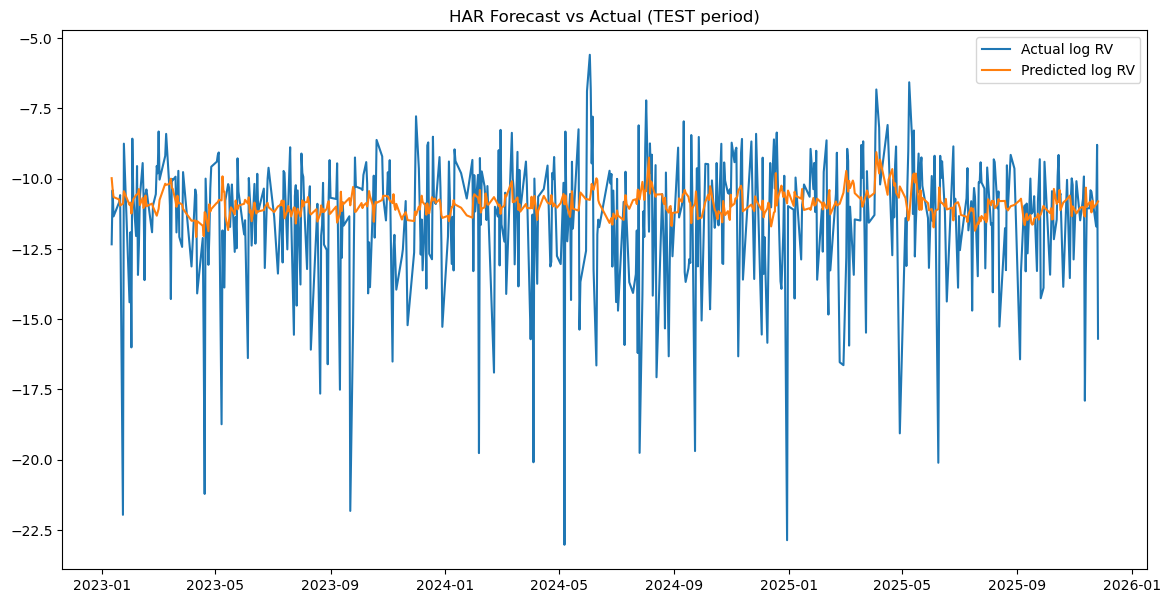

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))
plt.plot(y_test.index, y_test, label='Actual log RV')
plt.plot(y_test.index, pred_test, label='Predicted log RV')
plt.title("HAR Forecast vs Actual (TEST period)")
plt.legend()
plt.show()


In [41]:
# Building a GARCH-X model to compliment HAR-RV
!pip install arch
from arch import arch_model



Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/930.4 kB ? eta -:--:--
   --------------------------------------- 930.4/930.4 kB 14.2 MB/s eta 0:00:00


In [47]:
rets_train = train_ref["NIFTY_ret"].dropna()
results = []

for p in range(1, 4):      # p = 1,2,3
    for q in range(1, 4):  # q = 1,2,3
        try:
            am = arch_model(
                rets_train,
                vol="GARCH",
                p=p, q=q,
                mean="Constant",
                dist="normal"
            )
            res = am.fit(disp="off")
            results.append({
                "p": p,
                "q": q,
                "AIC": res.aic,
                "BIC": res.bic,
                "LogLik": res.loglikelihood
            })
            print(f"Done GARCH({p},{q})  AIC={res.aic:.2f}, BIC={res.bic:.2f}")
        except Exception as e:
            print(f"Failed GARCH({p},{q}): {e}")


C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\vijee

Done GARCH(1,1)  AIC=-13214.37, BIC=-13191.91
Done GARCH(1,2)  AIC=-13206.87, BIC=-13178.79
Done GARCH(1,3)  AIC=-13200.71, BIC=-13167.03


C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\vijee

Done GARCH(2,1)  AIC=-13216.02, BIC=-13187.94
Done GARCH(2,2)  AIC=-13216.34, BIC=-13182.65
Done GARCH(2,3)  AIC=-13208.96, BIC=-13169.66
Done GARCH(3,1)  AIC=-13214.82, BIC=-13181.13


C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Done GARCH(3,2)  AIC=-13213.02, BIC=-13173.71
Done GARCH(3,3)  AIC=-13205.88, BIC=-13160.96


C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [48]:
res_df = pd.DataFrame(results)
print("\nSorted by BIC (lower is better):")
print(res_df.sort_values("BIC").head(10))



Sorted by BIC (lower is better):
   p  q           AIC           BIC       LogLik
0  1  1 -13214.366962 -13191.907741  6611.183481
3  2  1 -13216.018152 -13187.944125  6613.009076
4  2  2 -13216.338164 -13182.649331  6614.169082
6  3  1 -13214.821681 -13181.132849  6613.410840
1  1  2 -13206.868893 -13178.794866  6608.434447
7  3  2 -13213.015942 -13173.712305  6613.507971
5  2  3 -13208.961060 -13169.657423  6611.480530
2  1  3 -13200.714995 -13167.026162  6606.357497
8  3  3 -13205.877232 -13160.958789  6610.938616


In [50]:
best_p = 1
best_q = 1
best_garch = arch_model(
    rets_train,
    vol="GARCH",
    p=best_p, q=best_q,
    mean="Constant",
    dist="normal"
)

best_garch_res = best_garch.fit(update_freq=10, disp="off")
print(best_garch_res.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:              NIFTY_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                6611.18
Distribution:                  Normal   AIC:                          -13214.4
Method:            Maximum Likelihood   BIC:                          -13191.9
                                        No. Observations:                 2028
Date:                Sun, Nov 30 2025   Df Residuals:                     2027
Time:                        01:22:31   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         4.6441e-04  3.368e-05     13.790  2.921e-43 [3.

C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 9.397e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
# Building ML model only on HAR basis 
har_ml_features = [
    "log_NIFTY_RV",
    "log_NIFTY_RV_w",
    "log_SPX_RV",
    "log_SPX_RV_w",
    "dVIX",
    "FOMC_Window",
    "CPI_Window"
]


In [53]:
#Building ML model basd only on GARCH basis 
garch_ml_features = [
    "GARCH_sigma",   # or "GARCH_var"
    "NIFTY_ret",     # so the ML model knows recent shock
]


In [55]:
from arch import arch_model

# Combine everything if not already done
full_ref = pd.concat([train_ref, val_ref, test_ref], axis=0).sort_index()

# Take full NIFTY returns series
rets_full = full_ref["NIFTY_ret"].dropna()

# Fit GARCH(1,1) on the full sample (same spec as earlier)
garch_full = arch_model(
    rets_full,
    vol="GARCH",
    p=1, q=1,
    mean="Constant",
    dist="normal"
)

garch_full_res = garch_full.fit(update_freq=10, disp="off")
print(garch_full_res.summary())

# Get conditional volatility and variance
garch_sigma_full = garch_full_res.conditional_volatility
garch_var_full   = garch_sigma_full ** 2

# Align back into full_ref
full_ref.loc[garch_sigma_full.index, "GARCH_sigma"] = garch_sigma_full
full_ref.loc[garch_var_full.index,   "GARCH_var"]   = garch_var_full

print(full_ref[["NIFTY_ret", "GARCH_sigma", "GARCH_var"]].tail())


C:\Users\vijeet\AppData\Roaming\Python\Python312\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001088. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:              NIFTY_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                10464.6
Distribution:                  Normal   AIC:                          -20921.2
Method:            Maximum Likelihood   BIC:                          -20896.9
                                        No. Observations:                 3206
Date:                Thu, Dec 04 2025   Df Residuals:                     3205
Time:                        17:56:28   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         6.0342e-04  4.532e-05     13.314  1.926e-40 [5.

In [56]:
# --- ML(HAR) datasets ---
train_har = full_ref.loc[train_ref.index].dropna(subset=har_ml_features + ["log_TARGET"])
val_har   = full_ref.loc[val_ref.index].dropna(subset=har_ml_features + ["log_TARGET"])
test_har  = full_ref.loc[test_ref.index].dropna(subset=har_ml_features + ["log_TARGET"])

X_train_har = train_har[har_ml_features]
y_train_har = train_har["log_TARGET"]

X_val_har   = val_har[har_ml_features]
y_val_har   = val_har["log_TARGET"]

X_test_har  = test_har[har_ml_features]
y_test_har  = test_har["log_TARGET"]

# --- ML(GARCH) datasets ---
train_garch = full_ref.loc[train_ref.index].dropna(subset=garch_ml_features + ["log_TARGET"])
val_garch   = full_ref.loc[val_ref.index].dropna(subset=garch_ml_features + ["log_TARGET"])
test_garch  = full_ref.loc[test_ref.index].dropna(subset=garch_ml_features + ["log_TARGET"])

X_train_garch = train_garch[garch_ml_features]
y_train_garch = train_garch["log_TARGET"]

X_val_garch   = val_garch[garch_ml_features]
y_val_garch   = val_garch["log_TARGET"]

X_test_garch  = test_garch[garch_ml_features]
y_test_garch  = test_garch["log_TARGET"]

print("HAR train shape:", X_train_har.shape)
print("GARCH train shape:", X_train_garch.shape)


HAR train shape: (2028, 7)
GARCH train shape: (2028, 2)


In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def run_rf(X_train, y_train, X_val, y_val, X_test, y_test, label=""):
    print(f"\n==================== {label} ====================")
    
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X_train, y_train)
    
    def eval_split(name, X, y):
        pred = rf.predict(X)
        rmse = np.sqrt(mean_squared_error(y, pred))
        mae  = mean_absolute_error(y, pred)
        print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}")
        return pred
    
    pred_train = eval_split("Train", X_train, y_train)
    pred_val   = eval_split("Validation", X_val, y_val)
    pred_test  = eval_split("Test", X_test, y_test)
    
    return rf, pred_train, pred_val, pred_test


In [59]:
rf_har, har_train_pred, har_val_pred, har_test_pred = run_rf(
    X_train_har, y_train_har,
    X_val_har, y_val_har,
    X_test_har, y_test_har,
    label="ML(HAR-RV)"
)



==================== ML(HAR-RV) ====================
Train: RMSE=2.1749, MAE=1.6341
Validation: RMSE=2.3186, MAE=1.8072
Test: RMSE=2.5135, MAE=1.7877


In [60]:
rf_garch, garch_train_pred, garch_val_pred, garch_test_pred = run_rf(
    X_train_garch, y_train_garch,
    X_val_garch, y_val_garch,
    X_test_garch, y_test_garch,
    label="ML(GARCH)"
)



==================== ML(GARCH) ====================
Train: RMSE=2.2163, MAE=1.6650
Validation: RMSE=2.3381, MAE=1.8321
Test: RMSE=2.5117, MAE=1.8453


In [61]:
# Building a hybrid ML model using HAR +GARCH 
# Hybrid feature set = union of both
hybrid_ml_features = har_ml_features + garch_ml_features
print("Hybrid feature count:", len(hybrid_ml_features), hybrid_ml_features)


Hybrid feature count: 9 ['log_NIFTY_RV', 'log_NIFTY_RV_w', 'log_SPX_RV', 'log_SPX_RV_w', 'dVIX', 'FOMC_Window', 'CPI_Window', 'GARCH_sigma', 'NIFTY_ret']


In [62]:
# Use the same full_ref, aligned with train/val/test indices

train_hybrid = full_ref.loc[train_ref.index].dropna(subset=hybrid_ml_features + ["log_TARGET"])
val_hybrid   = full_ref.loc[val_ref.index].dropna(subset=hybrid_ml_features + ["log_TARGET"])
test_hybrid  = full_ref.loc[test_ref.index].dropna(subset=hybrid_ml_features + ["log_TARGET"])

X_train_hybrid = train_hybrid[hybrid_ml_features]
y_train_hybrid = train_hybrid["log_TARGET"]

X_val_hybrid   = val_hybrid[hybrid_ml_features]
y_val_hybrid   = val_hybrid["log_TARGET"]

X_test_hybrid  = test_hybrid[hybrid_ml_features]
y_test_hybrid  = test_hybrid["log_TARGET"]

print("Hybrid train shape:", X_train_hybrid.shape)
print("Hybrid val shape:", X_val_hybrid.shape)
print("Hybrid test shape:", X_test_hybrid.shape)


Hybrid train shape: (2028, 9)
Hybrid val shape: (614, 9)
Hybrid test shape: (564, 9)


In [63]:
rf_hybrid, hybrid_train_pred, hybrid_val_pred, hybrid_test_pred = run_rf(
    X_train_hybrid, y_train_hybrid,
    X_val_hybrid,   y_val_hybrid,
    X_test_hybrid,  y_test_hybrid,
    label="ML(HAR + GARCH)"
)



==================== ML(HAR + GARCH) ====================
Train: RMSE=2.1469, MAE=1.6104
Validation: RMSE=2.2941, MAE=1.7841
Test: RMSE=2.4951, MAE=1.8121


In [64]:
#Comparing RV on scale 
from sklearn.metrics import mean_squared_error, mean_absolute_error

def eval_rv(y_true_log, y_pred_log, name=""):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"{name} - RMSE(RV): {rmse:.6f}, MAE(RV): {mae:.6f}")

print("\nHybrid model performance on RV scale:")
eval_rv(y_train_hybrid, hybrid_train_pred, "Train")
eval_rv(y_val_hybrid,   hybrid_val_pred,   "Validation")
eval_rv(y_test_hybrid,  hybrid_test_pred,  "Test")



Hybrid model performance on RV scale:
Train - RMSE(RV): 0.000192, MAE(RV): 0.000079
Validation - RMSE(RV): 0.000901, MAE(RV): 0.000186
Test - RMSE(RV): 0.000197, MAE(RV): 0.000051


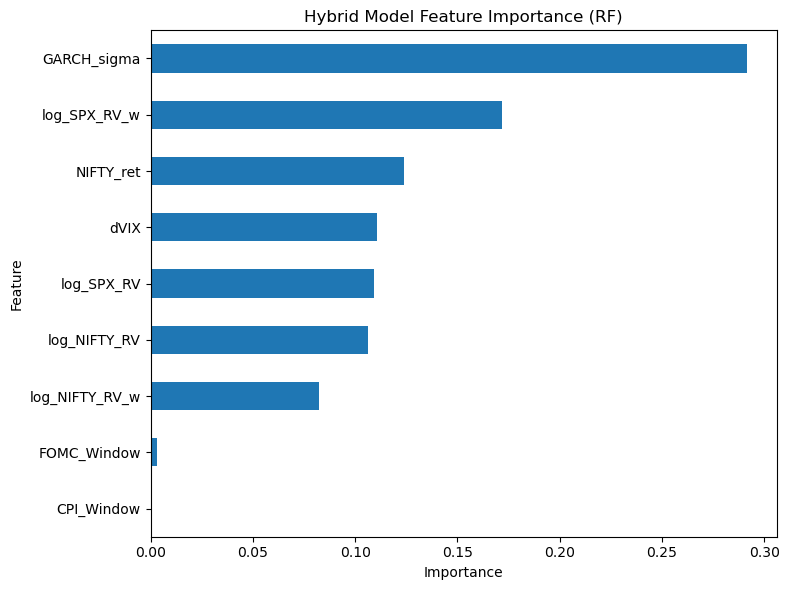

CPI_Window        0.000944
FOMC_Window       0.002936
log_NIFTY_RV_w    0.082408
log_NIFTY_RV      0.106219
log_SPX_RV        0.109214
dVIX              0.110844
NIFTY_ret         0.123994
log_SPX_RV_w      0.171966
GARCH_sigma       0.291474
dtype: float64

In [65]:
# Feature importance from the hybrid RF
imp = pd.Series(rf_hybrid.feature_importances_, index=hybrid_ml_features)
imp_sorted = imp.sort_values()

plt.figure(figsize=(8, 6))
imp_sorted.plot(kind="barh")
plt.title("Hybrid Model Feature Importance (RF)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

imp_sorted


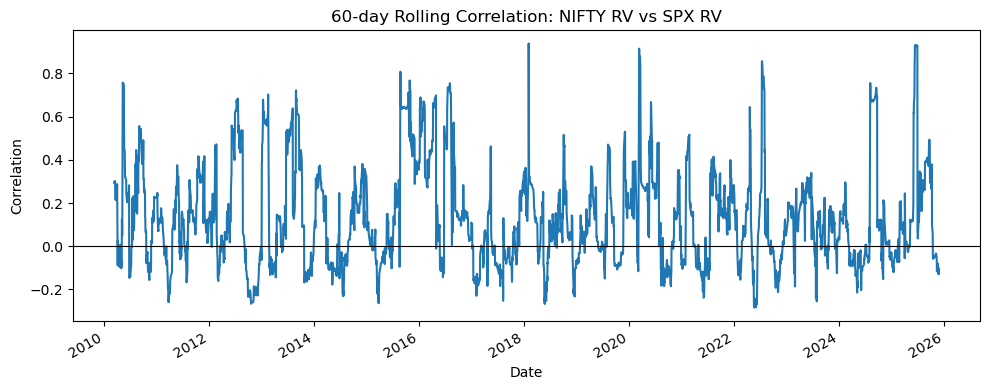

In [71]:
# Make sure RV columns exist
full_ref["NIFTY_RV"] = full_ref["NIFTY_rv_sq"]
full_ref["SPX_RV"]   = full_ref["SPX_rv_sq"]

# 60-day rolling correlation
roll_corr = full_ref[["NIFTY_RV", "SPX_RV"]].rolling(30).corr().unstack().iloc[:,1]

plt.figure(figsize=(10,4))
roll_corr.plot()
plt.axhline(0, color="black", linewidth=0.8)
plt.title("60-day Rolling Correlation: NIFTY RV vs SPX RV")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()


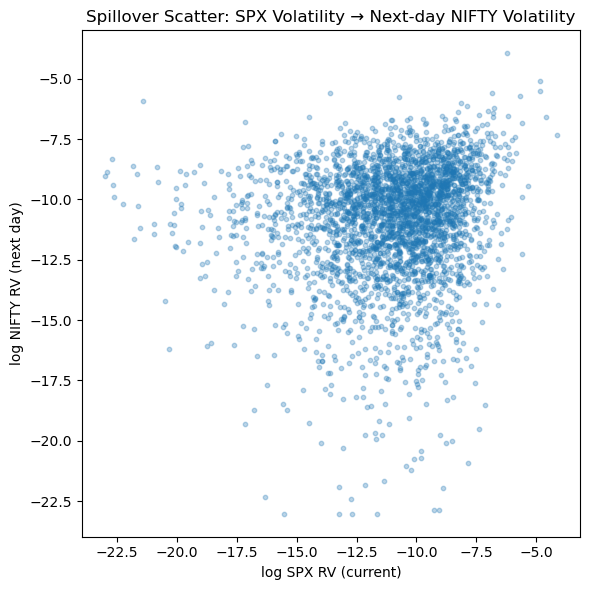

In [67]:
# Next day nifty vol vs spx vol 
plt.figure(figsize=(6,6))
plt.scatter(full_ref["log_SPX_RV"], full_ref["log_TARGET"], alpha=0.3, s=10)
plt.xlabel("log SPX RV (current)")
plt.ylabel("log NIFTY RV (next day)")
plt.title("Spillover Scatter: SPX Volatility → Next-day NIFTY Volatility")
plt.tight_layout()
plt.show()


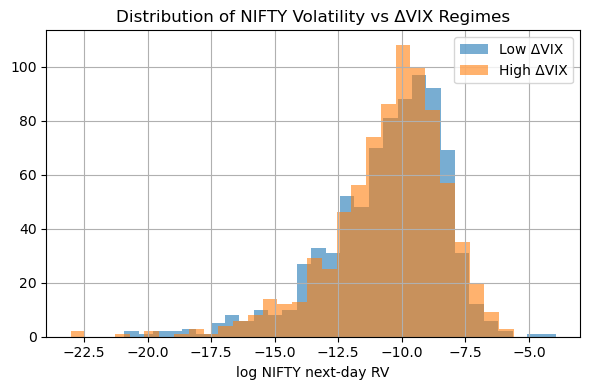

In [68]:
# Define regimes based on dVIX
high_dvix = full_ref["dVIX"] > full_ref["dVIX"].quantile(0.75)
low_dvix  = full_ref["dVIX"] < full_ref["dVIX"].quantile(0.25)

plt.figure(figsize=(6,4))
full_ref.loc[low_dvix, "log_TARGET"].hist(alpha=0.6, bins=30, label="Low ΔVIX")
full_ref.loc[high_dvix, "log_TARGET"].hist(alpha=0.6, bins=30, label="High ΔVIX")
plt.legend()
plt.xlabel("log NIFTY next-day RV")
plt.title("Distribution of NIFTY Volatility vs ΔVIX Regimes")
plt.tight_layout()
plt.show()


In [69]:

spill_X = full_ref[["log_SPX_RV", "log_SPX_RV_w", "dVIX"]].dropna()
spill_y = full_ref.loc[spill_X.index, "log_TARGET"]

spill_Xc = sm.add_constant(spill_X)
spill_model = sm.OLS(spill_y, spill_Xc).fit(cov_type="HAC", cov_kwds={"maxlags":5})
print(spill_model.summary())


                            OLS Regression Results                            
Dep. Variable:             log_TARGET   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     33.17
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           4.18e-21
Time:                        19:02:46   Log-Likelihood:                -7319.2
No. Observations:                3206   AIC:                         1.465e+04
Df Residuals:                    3202   BIC:                         1.467e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -7.2482      0.406    -17.850   

In [75]:
# One day ahead analysis 
last_row = full_ref.iloc[-1:][hybrid_ml_features]
forecast_logrv = rf_hybrid.predict(last_row)[0]
forecast_rv = np.exp(forecast_logrv)

print("Next day forecasted RV:", forecast_rv)


Next day forecasted RV: 9.720257175670139e-06
